# Bootcamp Python - PY4
## Modulo 2: Machine Learning Avanzado y Feature Engineering
### Sesion 1: Análisis exploratorio de datos y preparación de datos

**Actividad evaluada relacionada:** Segmentacion de perfiles basada en algoritmos no supervisados.

---

### Contexto del escenario

Te uniste a un equipo donde los datos de usuarios no tienen etiquetas previas (no sabemos de
antemano a que grupo pertenece cada cliente). Tu mision es descubrir grupos naturales (clusters)
para que el equipo de marketing pueda personalizar sus estrategias segun comportamientos reales.

En esta primera sesion vamos a trabajar la **Fase 1** del proyecto:

1. Explorar el dataset (nulos, distribuciones, outliers).
2. Construir un Pipeline de Scikit-learn con imputacion y escalado.

El dataset que usaremos es **Credit Card Customer**: informacion de comportamiento de uso de tarjetas
de credito de aproximadamente 9000 clientes durante 6 meses (balance, compras, adelantos de
efectivo, limite de credito, pagos, etc.). No tiene una variable objetivo (target): es un
problema no supervisado.

### Por que aprendizaje no supervisado

En los modulos anteriores trabajamos con modelos supervisados: teniamos una variable objetivo
(`y`) que el modelo intentaba predecir a partir de las features (`X`).

En clustering no existe esa variable objetivo. Solo tenemos features, y el algoritmo debe
encontrar estructura y agrupaciones por si mismo, basandose unicamente en que tan "parecidos"
son los registros entre si (generalmente medido con distancias).

Esto tiene una consecuencia muy importante para hoy: como los algoritmos de clustering se basan
en **distancias**, la escala de las variables importa muchisimo. Si una variable esta en miles
(por ejemplo `BALANCE`) y otra va de 0 a 1 (por ejemplo `BALANCE_FREQUENCY`), la variable con
valores mas grandes va a dominar el calculo de distancia aunque no sea la mas importante para el
negocio. Por eso el escalado (scaling) no es opcional, es un requisito tecnico.

### Paso 0: Configuracion inicial

Importamos las librerias que vamos a necesitar durante toda la sesion:

- `pandas` y `numpy` para manipulacion de datos.
- `matplotlib` y `seaborn` para visualizacion.
- Herramientas de `scikit-learn` para el pipeline de preprocesamiento (`SimpleImputer`,
  `StandardScaler`, `Pipeline`, `ColumnTransformer`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

sns.set_style("white")
pd.set_option("display.max_columns", None)


### Diccionario de datos: CC_GENERAL

| Columna | Descripcion |
|---|---|
| `CUST_ID` | Identificador unico de cada cliente. No es una feature de comportamiento. |
| `BALANCE` | Monto disponible en la cuenta del cliente para hacer compras. |
| `BALANCE_FREQUENCY` | Que tan seguido se actualiza el balance, entre 0 y 1 (1 = se actualiza frecuentemente, 0 = casi no se actualiza). |
| `PURCHASES` | Monto total de compras realizadas por el cliente. |
| `ONEOFF_PURCHASES` | Monto maximo de compras realizadas en un solo pago (one-off). |
| `INSTALLMENTS_PURCHASES` | Monto total de compras realizadas en cuotas (installments). |
| `CASH_ADVANCE` | Monto de adelantos de efectivo (cash advance) que el cliente ha solicitado. |
| `PURCHASES_FREQUENCY` | Que tan seguido se hacen compras, entre 0 y 1 (1 = compra frecuentemente, 0 = casi nunca compra). |
| `ONEOFF_PURCHASES_FREQUENCY` | Que tan seguido se hacen compras en un solo pago, entre 0 y 1. |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | Que tan seguido se hacen compras en cuotas, entre 0 y 1. |
| `CASH_ADVANCE_FREQUENCY` | Que tan seguido el cliente pide adelantos de efectivo, entre 0 y 1. |
| `CASH_ADVANCE_TRX` | Numero de transacciones hechas con adelantos de efectivo. |
| `PURCHASES_TRX` | Numero de transacciones de compra realizadas. |
| `CREDIT_LIMIT` | Limite de credito de la tarjeta del cliente. |
| `PAYMENTS` | Monto total de pagos realizados por el cliente. |
| `MINIMUM_PAYMENTS` | Monto minimo de pagos realizados por el cliente. |
| `PRC_FULL_PAYMENT` | Porcentaje de veces que el cliente pago el total de su deuda de una vez (full payment). |
| `TENURE` | Numero de meses (antiguedad) que el cliente lleva usando el servicio de la tarjeta de credito. |

### Paso 1: Cargar el dataset

Vamos a leer el archivo `CC_GENERAL.csv` directamente desde el repositorio de GitHub del curso.

In [6]:
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/"

df = pd.read_csv(BASE_URL + "CC_GENERAL.csv")
df.columns = df.columns.str.capitalize()
df.head()


,Cust_id,Balance,Balance_frequency,Purchases,Oneoff_purchases,Installments_purchases,Cash_advance,Purchases_frequency,Oneoff_purchases_frequency,Purchases_installments_frequency,Cash_advance_frequency,Cash_advance_trx,Purchases_trx,Credit_limit,Payments,Minimum_payments,Prc_full_payment,Tenure
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Paso 2: Primera exploracion (shape, tipos, columnas)

Antes de cualquier grafico, siempre conviene responder preguntas basicas:

- Cuantas filas y columnas tiene el dataset.
- Que tipo de dato tiene cada columna (`int`, `float`, `object`).
- Si hay alguna columna que claramente no es una feature de comportamiento (por ejemplo, un
  identificador de cliente que no aporta informacion para el clustering).

In [ ]:
print("Shape del dataset:", df.shape)
df.info()


Shape del dataset: (8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Cust_id                           8950 non-null   object 
 1   Balance                           8950 non-null   float64
 2   Balance_frequency                 8950 non-null   float64
 3   Purchases                         8950 non-null   float64
 4   Oneoff_purchases                  8950 non-null   float64
 5   Installments_purchases            8950 non-null   float64
 6   Cash_advance                      8950 non-null   float64
 7   Purchases_frequency               8950 non-null   float64
 8   Oneoff_purchases_frequency        8950 non-null   float64
 9   Purchases_installments_frequency  8950 non-null   float64
 10  Cash_advance_frequency            8950 non-null   float64
 11  Cash_advance_trx                  8950 

Observa la columna `CUST_ID`. Es un identificador unico de cliente (texto), no una
caracteristica de comportamiento. Para el clustering la vamos a descartar mas adelante, pero por
ahora la dejamos en el DataFrame para no perder trazabilidad.

### Paso 3: Estadisticas descriptivas

`describe()` nos da un resumen rapido (media, desviacion estandar, minimo, maximo, cuartiles)
para cada variable numerica. Esto nos ayuda a detectar rangos muy distintos entre variables
(justo el problema que resuelve el escalado) y posibles valores extremos.

In [ ]:
df.describe().round().T


,count,mean,std,min,25%,50%,75%,max
Balance,8950.0,1564.0,2082.0,0.0,128.0,873.0,2054.0,19043.0
Balance_frequency,8950.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
Purchases,8950.0,1003.0,2137.0,0.0,40.0,361.0,1110.0,49040.0
Oneoff_purchases,8950.0,592.0,1660.0,0.0,0.0,38.0,577.0,40761.0
Installments_purchases,8950.0,411.0,904.0,0.0,0.0,89.0,469.0,22500.0
Cash_advance,8950.0,979.0,2097.0,0.0,0.0,0.0,1114.0,47137.0
Purchases_frequency,8950.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
Oneoff_purchases_frequency,8950.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Purchases_installments_frequency,8950.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
Cash_advance_frequency,8950.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


### Paso 4: Analisis de valores nulos

Un pipeline de Machine Learning no puede recibir valores nulos (`NaN`). Necesitamos saber:

- Cuantos nulos tiene cada columna.
- Que porcentaje representan sobre el total de filas.

Esto nos va a permitir decidir la estrategia de imputacion en el pipeline (por ejemplo, imputar
con la mediana si son pocos nulos y la variable tiene outliers).

In [ ]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    "nulos": nulos,
    "porcentaje": porcentaje_nulos.round(2)
})

resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("nulos", ascending=False)


,nulos,porcentaje
Minimum_payments,313,3.50
Credit_limit,1,0.01


### Paso 5: Distribuciones de las variables (histogramas)

Ahora que sabemos que columnas tienen nulos, miremos como se distribuyen los valores. Muchas
variables de comportamiento financiero (balance, compras, pagos) suelen tener una distribucion
con **cola larga a la derecha**: la mayoria de los clientes gasta poco, y unos pocos gastan
muchisimo. Esto es relevante porque algunas transformaciones (como Log-transform) que vimos en
la teoria sirven justamente para corregir este tipo de sesgo (skewness).

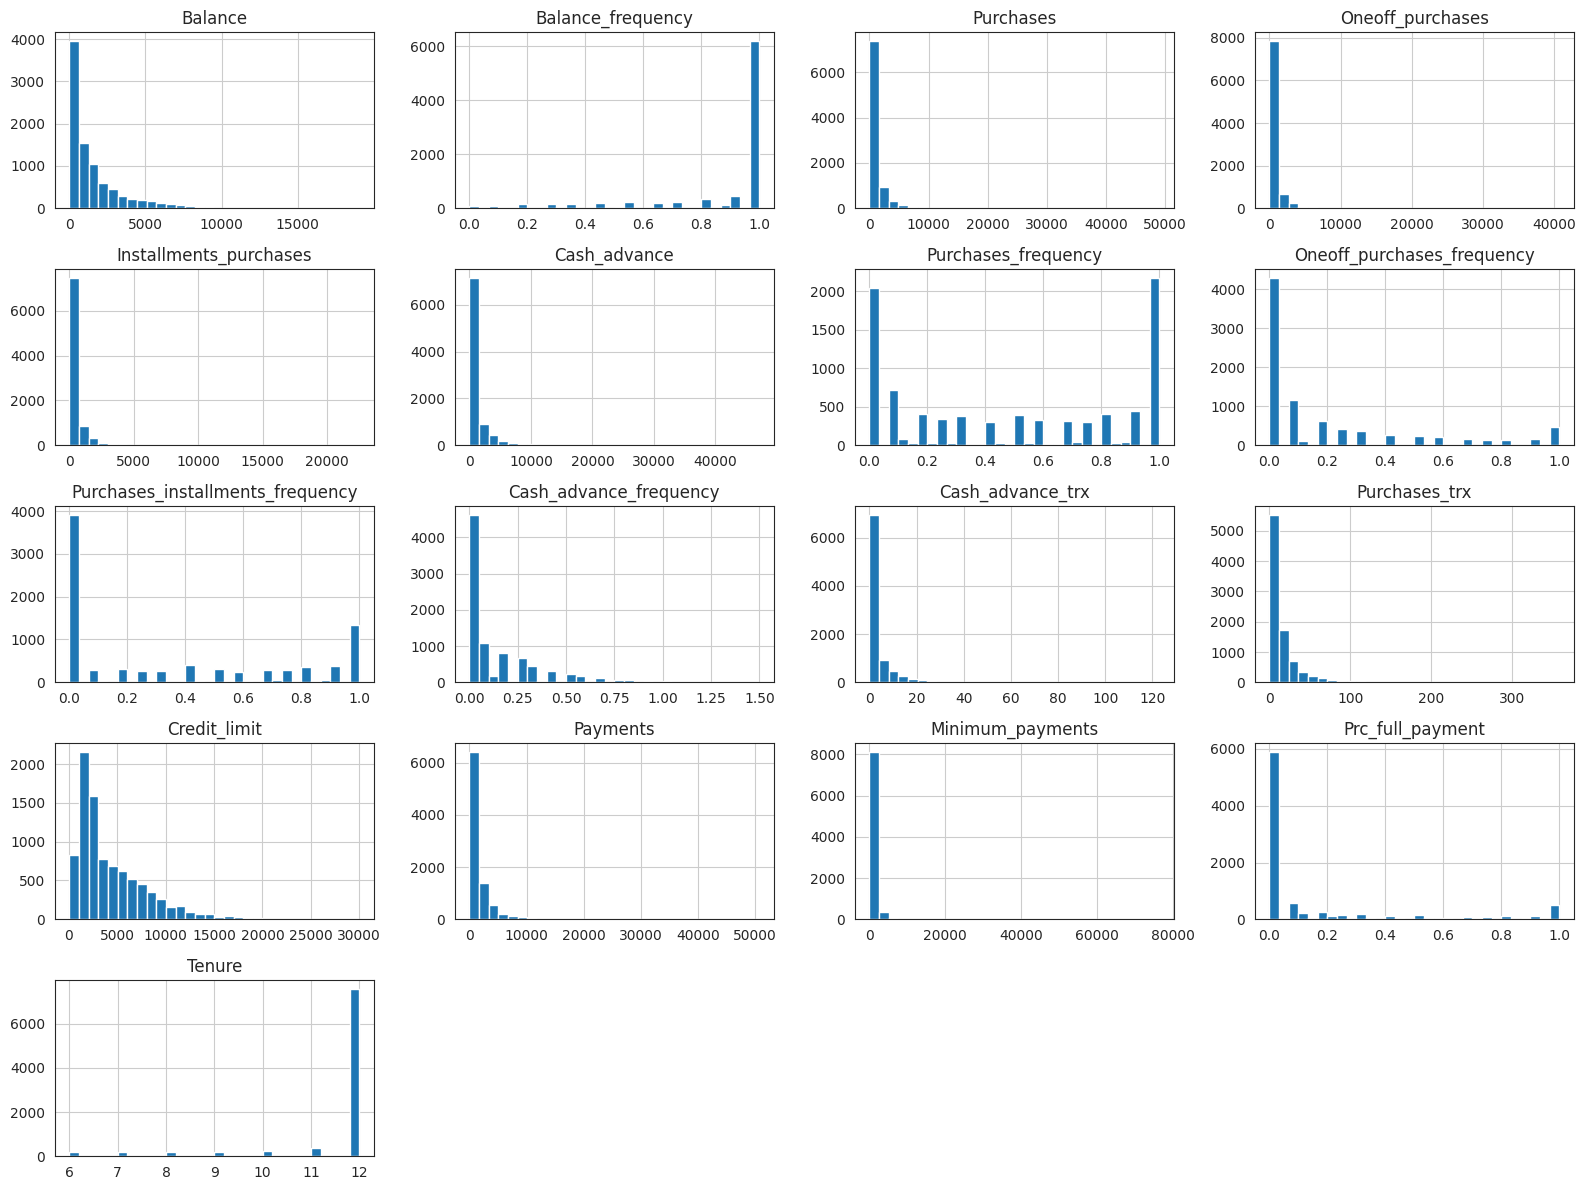

In [ ]:
columnas_numericas = df.drop(columns=["Cust_id"]).columns

df[columnas_numericas].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


### Paso 6: Deteccion visual de outliers (boxplots)

Los boxplots nos ayudan a visualizar rapidamente los valores atipicos (outliers) de cada
variable. Vamos a mirar en detalle algunas de las variables mas relevantes para el negocio:
`BALANCE`, `PURCHASES`, `CASH_ADVANCE` y `CREDIT_LIMIT`.

Recuerda: no siempre hay que eliminar los outliers. A veces son
justamente los clientes mas interesantes para marketing (por ejemplo, clientes con gasto muy
alto).

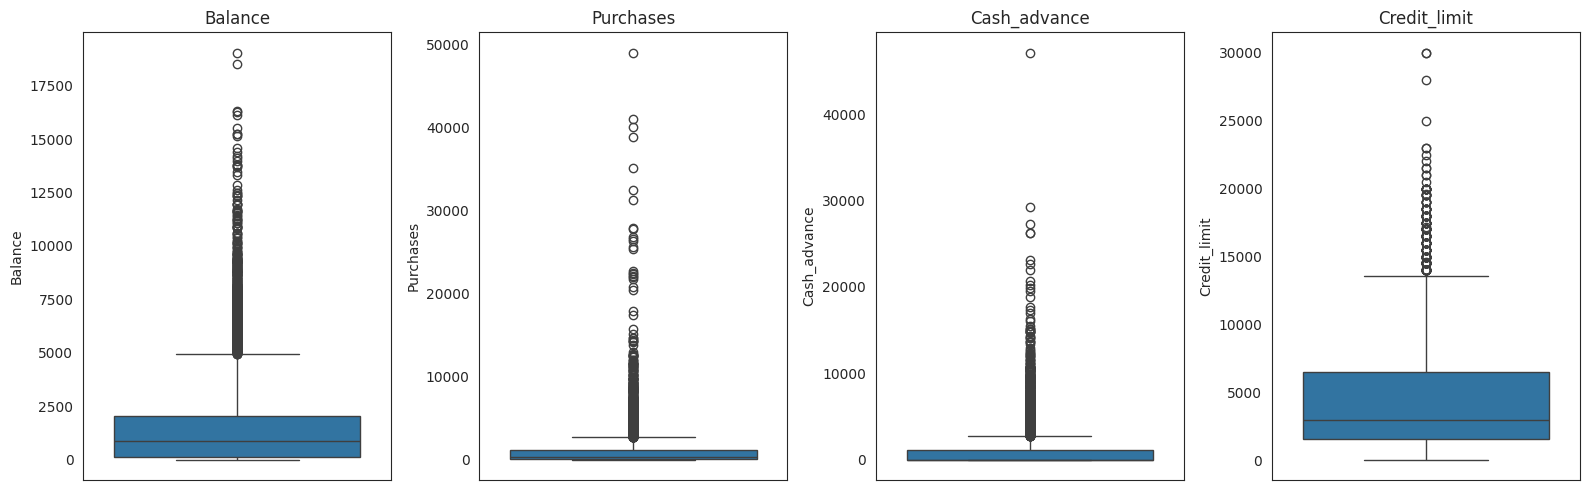

In [ ]:
variables_clave = ["Balance", "Purchases", "Cash_advance", "Credit_limit"]

fig, axes = plt.subplots(1, len(variables_clave), figsize=(16, 5))

for ax, columna in zip(axes, variables_clave): # zip() empareja cada eje (ax) con una variable para dibujar un boxplot en cada subplot
    sns.boxplot(y=df[columna], ax=ax)
    ax.set_title(columna)

plt.tight_layout()
plt.show()


### Paso 7: Matriz de correlacion

Antes de construir el pipeline, es util ver que tan correlacionadas estan las variables entre
si. Esto no cambia el preprocesamiento de hoy, pero nos sirve para entender por que mas adelante
(sesion 2) vamos a aplicar PCA: si muchas variables estan altamente correlacionadas, contienen
informacion redundante y se pueden resumir en menos dimensiones.

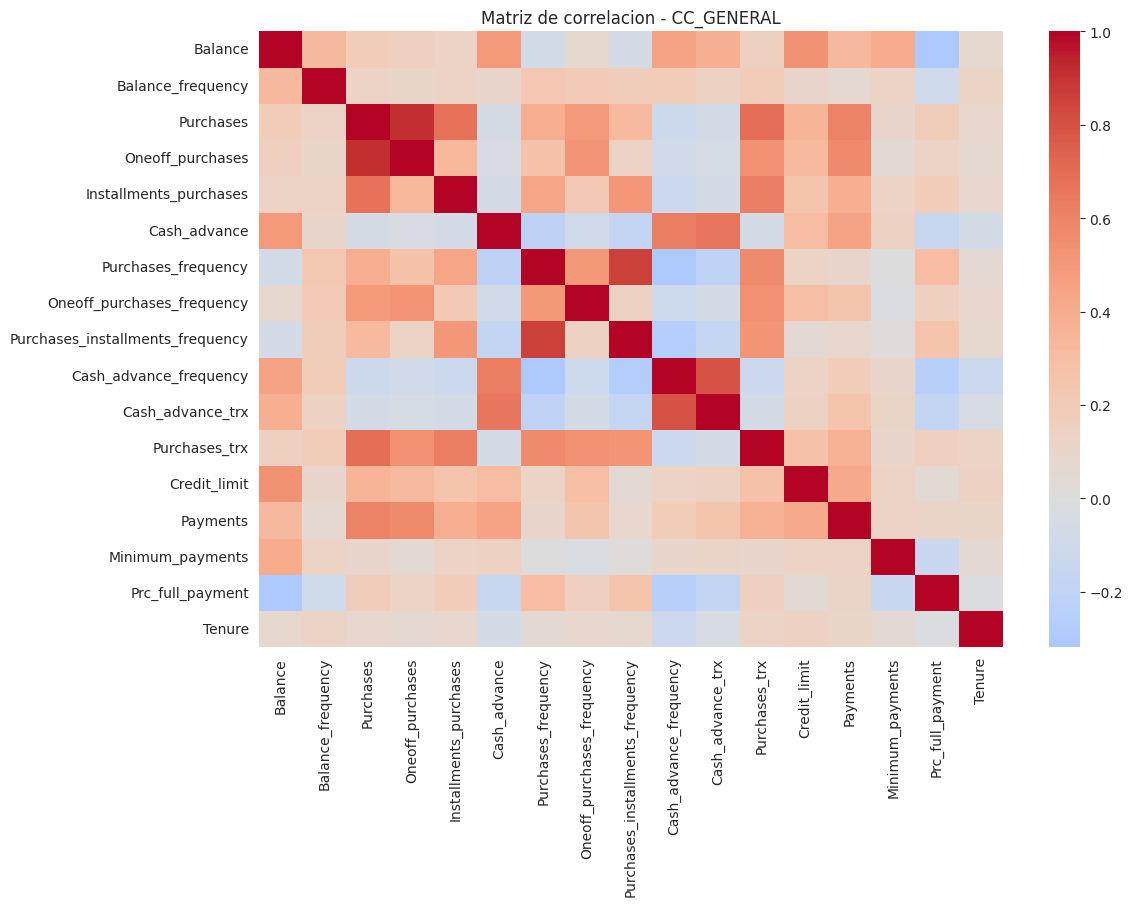

In [ ]:
plt.figure(figsize=(12, 8))
correlacion = df[columnas_numericas].corr()
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlacion - CC_GENERAL")
plt.show()


### Paso 8: Construccion del Pipeline de preprocesamiento

Con lo que exploramos, ya podemos construir el pipeline tecnico:

1. **Eliminar `CUST_ID`**: no es una feature de comportamiento.
2. **Imputacion**: reemplazar los valores nulos. Usaremos la **mediana**, porque es mas robusta
   frente a los outliers que ya identificamos (a diferencia de la media).
3. **Escalado**: usaremos `StandardScaler`, que transforma cada variable para que tenga media 0
   y desviacion estandar 1. Esto es clave porque K-Means, DBSCAN y GMM se basan en distancias.

Vamos a usar `Pipeline` de Scikit-learn para encadenar estos pasos de forma prolija y
reproducible.

In [ ]:
# Separamos el identificador (no es una feature) del resto de columnas
features = df.drop(columns=["Cust_id"])
customer_ids = df["Cust_id"]

# Definimos el pipeline de preprocesamiento numerico
pipeline_preprocesamiento = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) # transforma las variable para que media=0 y std=1
])

pipeline_preprocesamiento


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

### Imputacion: Mediana o Media ?

La **mediana** es el valor central de un conjunto de datos una vez ordenados de menor a mayor.

**Ejemplo:**

`2, 4, 5, 7, 10`

La mediana es **5**, ya que es el valor que queda en el centro.

Si existe un valor extremo:

`2, 4, 5, 7, 100`

La **media** es **23.6**, mientras que la **mediana** sigue siendo **5**.

Por esta razón, la mediana suele utilizarse para reemplazar valores faltantes cuando la variable presenta **outliers**, ya que representa mejor el valor típico de los datos.

### Paso 9: Aplicar el pipeline (fit_transform)

Ahora ajustamos (`fit`) el pipeline sobre nuestras features y lo aplicamos (`transform`) en un
solo paso con `fit_transform`. El resultado es un arreglo de NumPy, asi que lo convertimos de
nuevo a un DataFrame para poder inspeccionarlo facilmente.

In [ ]:
features_procesadas = pipeline_preprocesamiento.fit_transform(features)

df_procesado = pd.DataFrame(features_procesadas, columns=features.columns)
df_procesado.head()


,Balance,Balance_frequency,Purchases,Oneoff_purchases,Installments_purchases,Cash_advance,Purchases_frequency,Oneoff_purchases_frequency,Purchases_installments_frequency,Cash_advance_frequency,Cash_advance_trx,Purchases_trx,Credit_limit,Payments,Minimum_payments,Prc_full_payment,Tenure
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


### Paso 10: Verificacion

Una buena practica despues de escalar es verificar que efectivamente cada columna quedo con
media aproximadamente 0 y desviacion estandar aproximadamente 1. Tambien confirmamos que ya no
quedan valores nulos.

In [ ]:
print("Nulos restantes:", df_procesado.isnull().sum().sum())
print()
print("Media por columna (deberia ser cercana a 0):")
print(df_procesado.mean().round(2))
print()
print("Desviacion estandar por columna (deberia ser cercana a 1):")
print(df_procesado.std().round(2))


Nulos restantes: 0

Media por columna (deberia ser cercana a 0):
Balance                            -0.0
Balance_frequency                   0.0
Purchases                           0.0
Oneoff_purchases                   -0.0
Installments_purchases              0.0
Cash_advance                       -0.0
Purchases_frequency                 0.0
Oneoff_purchases_frequency          0.0
Purchases_installments_frequency    0.0
Cash_advance_frequency             -0.0
Cash_advance_trx                   -0.0
Purchases_trx                      -0.0
Credit_limit                        0.0
Payments                           -0.0
Minimum_payments                    0.0
Prc_full_payment                   -0.0
Tenure                              0.0
dtype: float64

Desviacion estandar por columna (deberia ser cercana a 1):
Balance                             1.0
Balance_frequency                   1.0
Purchases                           1.0
Oneoff_purchases                    1.0
Installments_purchas

### Cierre de la sesion

Hoy avanzamos en:

- Exploracion de nulos, distribuciones y outliers del dataset `CC_GENERAL`.
- Construccion de un Pipeline de Scikit-learn con `SimpleImputer` y `StandardScaler`.
- Datos listos (`df_procesado`) para ser usados por algoritmos de clustering.

**Para la proxima sesion (Sesion 2):** vamos a reducir la dimensionalidad de estos datos con
PCA, visualizar los datos en 2D, y entrenar nuestro primer modelo de clustering (K-Means),
usando el Metodo del Codo y el Coeficiente de Silueta para justificar el numero de clusters.